# Импорт библиотек

##  python -m pip install  ipykernel seaborn numpy pandas matplotlib scikit-learn


In [1]:
import pandas as pd
import numpy as np

# Инструменты для пайплайна и валидации
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Инструменты предобработки
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Модель классификации
from sklearn.neighbors import KNeighborsClassifier

# Бизнес-метрики качества
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

**Вывод:** Подключены библиотеки для обработки данных, построения моделей машинного обучения, подбора параметров и оценки качества предсказаний.

In [2]:
df = pd.read_csv("insurance.csv")

# баланс классов (целевая переменная - smoker: 0 - не курит, 1 - курит)
class_counts = df["smoker"].value_counts(normalize=True) * 100
print(f'Баланс классов:\nНе курят: {class_counts.get("no", 0):.1f}%\nКурят: {class_counts.get("yes", 0):.1f}%')

# Делаем выборку
X = df.drop(["smoker", "charges"], axis=1)
y = df["smoker"].map({"no": 0, "yes": 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(df.columns)


Баланс классов:
Не курят: 79.5%
Курят: 20.5%
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')


**Вывод:** Датасет загружен и подготовлен для обучения модели. Целевой признак `smoker` показывает, курит человек или нет. Данные разделены на обучающую и тестовую выборки с сохранением пропорций классов.

In [3]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "region"]

# Ветка 1: Обработка чисел
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)
# Ветка 2: Обработка категорий (текста)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)
# 1 + 2
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
# Итоговый конвейер: Предобработка -> Модель
clf_pipline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier())
    ]
)
# Сетка поиска
param_grid = {
    "classifier__n_neighbors": [3, 5, 9],
    "classifier__weights": ["uniform", "distance"],
}
# 5-Fold кросс-валидация
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Сбор всего в одно
grid_search = GridSearchCV(
    estimator=clf_pipline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)
# Обучение
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print(f'\nЛучшие параметры алгоритма: {grid_search.best_params_}')



Лучшие параметры алгоритма: {'classifier__n_neighbors': 3, 'classifier__weights': 'uniform'}


**Вывод:** Для числовых признаков выполнены заполнение пропусков и масштабирование, а категориальные признаки преобразованы в числовой формат. С помощью кросс-валидации подобраны параметры модели KNN, предназначенной для определения статуса курения.

In [4]:
# Предскажем 0 или 1
y_pred = best_model.predict(X_test)

# Предсказание вероятностей от 0.0 до 1.0 (для ROC-AUC)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("--- Матрица ошибок ---")
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Истинно отрицательные (TN - не курит, предсказано не курит) {conf_matrix[0][0]}")
print(f"Ложноположительные (FP - не курит, предсказано курит) {conf_matrix[0][1]}")
print(f"Ложноотрицательные (FN - курит, предсказано не курит) {conf_matrix[1][0]}")
print(f"Истинно положительные (TP - курит, предсказано курит) {conf_matrix[1][1]}")

print("--- Отчет по метрикам ---")
print(classification_report(y_test, y_pred, target_names=["Не курит (0)", "Курит (1)"]))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"Площадь под кривой ROC-AUC: {roc_auc:.4f}")


--- Матрица ошибок ---
Истинно отрицательные (TN - не курит, предсказано не курит) 193
Ложноположительные (FP - не курит, предсказано курит) 20
Ложноотрицательные (FN - курит, предсказано не курит) 49
Истинно положительные (TP - курит, предсказано курит) 6
--- Отчет по метрикам ---
              precision    recall  f1-score   support

Не курит (0)       0.80      0.91      0.85       213
   Курит (1)       0.23      0.11      0.15        55

    accuracy                           0.74       268
   macro avg       0.51      0.51      0.50       268
weighted avg       0.68      0.74      0.70       268

Площадь под кривой ROC-AUC: 0.4939


**Вывод:** Качество классификации оценено с помощью матрицы ошибок, precision, recall, F1-score и ROC-AUC. Эти метрики позволяют оценить правильность предсказаний и способность модели различать курящих и некурящих людей. По результатам оценки можно определить, какие ошибки модель допускает чаще.

# Предсказание медицинских расходов (charges)


In [5]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

**Вывод:** Подключены инструменты для решения задачи регрессии. В отличие от классификации, здесь модель будет предсказывать числовое значение медицинских расходов.

In [6]:
df_reg = df.dropna(subset=["age", "bmi", "children", "charges"]).copy()
X_reg = df_reg[["age", "bmi", "children"]]
y_reg = df_reg["charges"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_pipline = Pipeline(
    [("scaler", StandardScaler()), ("knn_reg", KNeighborsRegressor())]
)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
param_dist = {
    "knn_reg__n_neighbors": np.arange(3, 30),
    "knn_reg__weights": ["uniform", "distance"],
}
random_search = RandomizedSearchCV(
    estimator=reg_pipline,
    param_distributions=param_dist,
    n_iter=10,
    cv=kf,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_r, y_train_r)
best_reg = random_search.best_estimator_
print(f'\nЛучшие параметры алгоритма: {random_search.best_params_}')



Лучшие параметры алгоритма: {'knn_reg__weights': 'uniform', 'knn_reg__n_neighbors': np.int64(27)}


**Вывод:** Для предсказания медицинских расходов выбрана модель KNN-регрессии. Числовые признаки масштабированы, данные разделены на обучающую и тестовую выборки, а параметры модели подобраны с помощью случайного поиска и кросс-валидации.

In [7]:
y_pred_r = best_reg.predict(X_test_r)

mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_r, y_pred_r)
smape_value = 100 * np.mean(
    2 * np.abs(y_pred_r - y_test_r) / (np.abs(y_test_r) + np.abs(y_pred_r))
)

print("--- Отчет по метрикам регрессии ---")
print(f"MSE (квадратные $) {mse:,.0f}")
print(f"RMSE ($) {rmse:,.2f}")
print(f"MAE (Средняя ошибка) {mae:,.2f}")
print(f"SMAPE (Ошибка в %) {smape_value:,.2f}")


--- Отчет по метрикам регрессии ---
MSE (квадратные $) 135,085,905
RMSE ($) 11,622.65
MAE (Средняя ошибка) 9,114.98
SMAPE (Ошибка в %) 72.60


**Вывод:** Качество регрессии оценено с помощью нескольких метрик ошибок. Они показывают, насколько предсказанные медицинские расходы отличаются от фактических. Чем меньше значения ошибок, тем точнее прогноз модели.

# Визуальный анализ

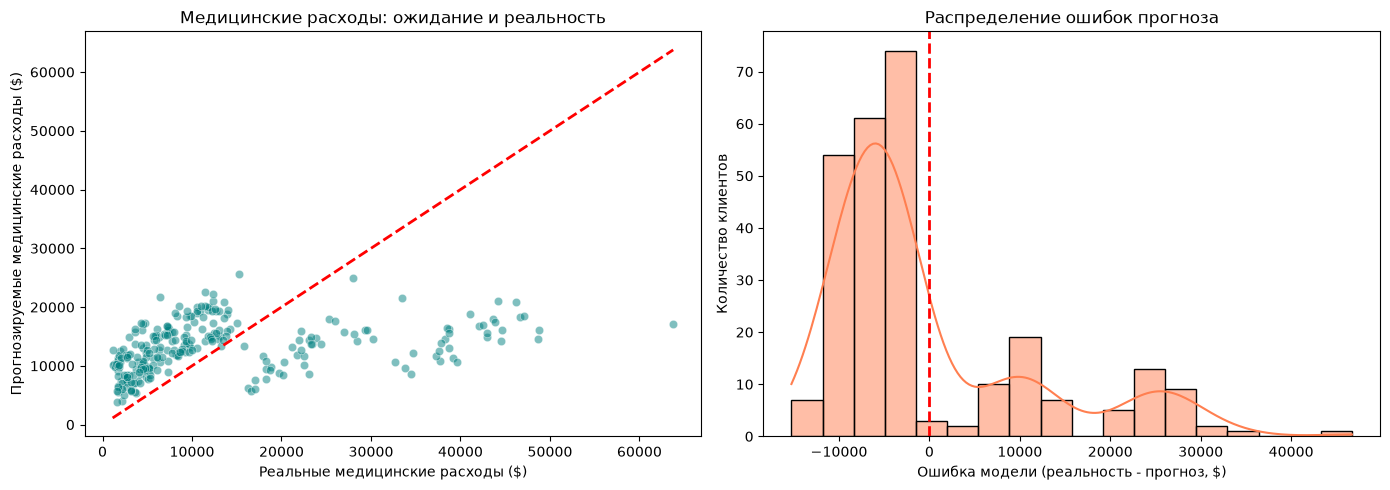

In [8]:
import typing_extensions
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1 График: Факт vs Прогноз
sns.scatterplot(x=y_test_r, y=y_pred_r, alpha=0.5, color="teal", ax=axes[0])
y_min = min(y_test_r.min(), y_pred_r.min())
y_max = max(y_test_r.max(), y_pred_r.max())
axes[0].plot([y_min, y_max], [y_min, y_max], "r--", lw=2)

axes[0].set_title("Медицинские расходы: ожидание и реальность")
axes[0].set_xlabel("Реальные медицинские расходы ($)")
axes[0].set_ylabel("Прогнозируемые медицинские расходы ($)")

# 2 График: Распределение ошибок
residuals = y_test_r - y_pred_r
sns.histplot(residuals, kde=True, color="coral", ax=axes[1])
axes[1].axvline(x=0, color="red", linestyle="--", lw=2) # Линия нулевой ошибки
axes[1].set_title("Распределение ошибок прогноза")
axes[1].set_xlabel("Ошибка модели (реальность - прогноз, $)")
axes[1].set_ylabel("Количество клиентов")

plt.tight_layout()
plt.show()


**Вывод:** На графике фактических и предсказанных расходов видно, насколько прогнозы соответствуют реальным значениям. График распределения остатков показывает характер и направление ошибок. Отклонения от линии идеального прогноза свидетельствуют о неточности модели, поэтому её предсказания не полностью совпадают с фактическими расходами.